# Music Genre Classification from Lyrics
**Course:** Deep Learning — University of Bologna

Classifichiamo il genere musicale di una canzone a partire dal testo dei testi.  
Confrontiamo due approcci:
1. **Baseline:** TF-IDF + MLP  
2. **Avanzato:** Fine-tuning di DistilBERT

In [4]:
!pip install kaggle transformers accelerate scikit-learn pandas numpy matplotlib seaborn tqdm

zsh:1: command not found: pip


In [ ]:
import os, json

KAGGLE_USERNAME = "*****"   
KAGGLE_KEY      = "*****"       

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
with open(os.path.join(kaggle_dir, "kaggle.json"), "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)

# Dataset: lyrics con 6 generi, ~28k canzoni, ancora disponibile su Kaggle
!kaggle datasets download -d neisse/scrapped-lyrics-from-6-genres -p . --unzip

# Verifica
import os
print("File scaricati:", [f for f in os.listdir(".") if f.endswith(".csv")])

Dataset URL: https://www.kaggle.com/datasets/neisse/scrapped-lyrics-from-6-genres
License(s): DbCL-1.0
100%|████████████████████████████████████████| 129M/129M [00:05<00:00, 27.0MB/s]

File scaricati: ['artists-data.csv', 'lyrics-data.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

artists = pd.read_csv("artists-data.csv")
lyrics  = pd.read_csv("lyrics-data.csv")

# Unisci su ALink / Link
df_raw = lyrics.merge(artists[["Link", "Genres"]], left_on="ALink", right_on="Link", how="left")
df_raw = df_raw[["Lyric", "Genres", "language"]].rename(columns={"Lyric": "lyrics", "Genres": "genre"})

print("Shape dopo merge:", df_raw.shape)
print(df_raw.head(3))

Shape dopo merge: (379931, 3)
                                              lyrics                genre  \
0  Tudo o que eu quero nessa vida,\nToda vida, é\...  Pop; Axé; Romântico   
1  Meu coração\nSem direção\nVoando só por voar\n...  Pop; Axé; Romântico   
2  É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...  Pop; Axé; Romântico   

  language  
0       pt  
1       pt  
2       pt  


In [3]:
# Questo dataset ha colonne: 'Genres', 'Lyrics' (o simili)
# Rinominiamo in modo standard dopo aver visto il nome reale sopra
print(df_raw.dtypes)
print("\nSample valori genres:", df_raw.iloc[:, -2].value_counts().head(10))

lyrics      str
genre       str
language    str
dtype: object

Sample valori genres: genre
Gospel/Religioso    20095
Sertanejo           10847
Rock                 5870
Romântico            5233
Forró                5114
Country              4790
Heavy Metal          4708
MPB                  4479
Indie                4364
Rap; Hip Hop         4274
Name: count, dtype: int64


In [4]:
# Ispezioniamo prima la struttura reale del dataset
print("Colonne:", df_raw.columns.tolist())
print("\nTipi:", df_raw.dtypes)
print("\nPrime righe:")
df_raw.head(3)

Colonne: ['lyrics', 'genre', 'language']

Tipi: lyrics      str
genre       str
language    str
dtype: object

Prime righe:


,lyrics,genre,language
0,"Tudo o que eu quero nessa vida,\nToda vida, é\...",Pop; Axé; Romântico,pt
1,Meu coração\nSem direção\nVoando só por voar\n...,Pop; Axé; Romântico,pt
2,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,Pop; Axé; Romântico,pt


In [5]:
df = df_raw[df_raw["language"] == "en"].copy()
df = df.drop(columns=["language"])
df = df.dropna()
df = df[df["lyrics"].str.strip() != ""]
df = df[df["genre"].str.strip() != ""]
df = df.reset_index(drop=True)
print("Shape solo inglese:", df.shape)

Shape solo inglese: (191378, 2)


In [6]:
df["genre"] = df["genre"].str.split(";").str[0].str.strip()
print(df["genre"].value_counts().head(10))

genre
Rock                25177
Pop                 13759
Heavy Metal         13496
Indie               12998
Rap                  9589
Pop/Rock             9019
Hip Hop              8412
Country              7377
Rock Alternativo     5555
R&B                  5309
Name: count, dtype: int64


genre
Rock             25177
Pop              13759
Heavy Metal      13496
Indie            12998
Rap               9589
                 ...  
Electro Swing        6
Jovem Guarda         6
Forró                3
Lo-fi                1
Regional             1
Name: count, Length: 73, dtype: int64


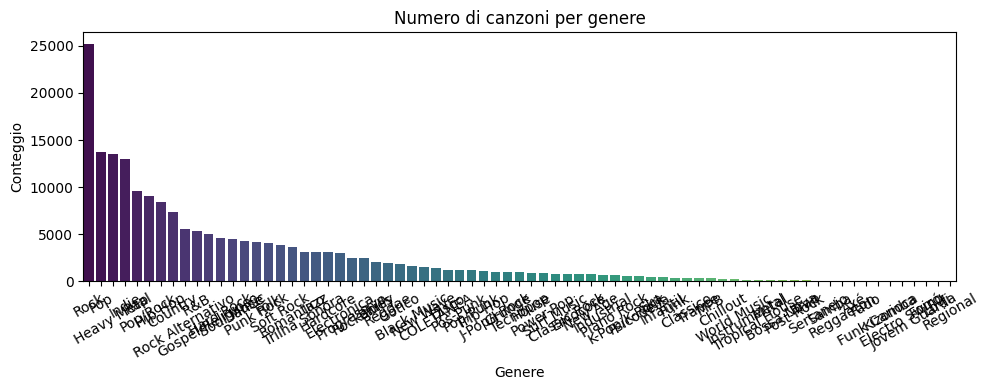

In [7]:
genre_counts = df["genre"].value_counts()
print(genre_counts)

plt.figure(figsize=(10, 4))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
plt.title("Numero di canzoni per genere")
plt.xlabel("Genere")
plt.ylabel("Conteggio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [8]:
TOP_GENRES = genre_counts.head(5).index.tolist()
print("Generi selezionati:", TOP_GENRES)

df = df[df["genre"].isin(TOP_GENRES)].reset_index(drop=True)
print("Shape filtrato:", df.shape)

Generi selezionati: ['Rock', 'Pop', 'Heavy Metal', 'Indie', 'Rap']
Shape filtrato: (75019, 2)


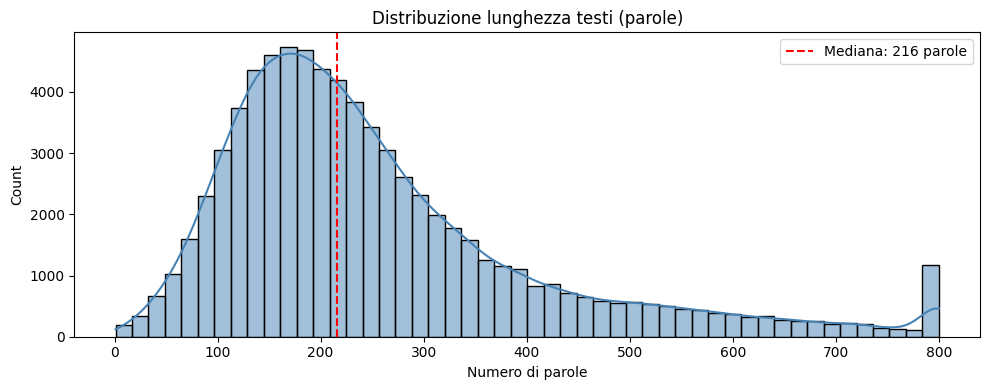

In [9]:
df["n_words"] = df["lyrics"].str.split().str.len()

plt.figure(figsize=(10, 4))
sns.histplot(df["n_words"].clip(upper=800), bins=50, kde=True, color="steelblue")
plt.axvline(df["n_words"].median(), color="red", linestyle="--",
            label=f"Mediana: {df['n_words'].median():.0f} parole")
plt.title("Distribuzione lunghezza testi (parole)")
plt.xlabel("Numero di parole")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import re

def clean_lyrics(text: str) -> str:
    text = re.sub(r"\[.*?\]", " ", text)      # rimuovi [Chorus], [Verse 1], ecc.
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # solo lettere
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["lyrics"].apply(clean_lyrics)
df = df[df["clean"].str.strip() != ""].reset_index(drop=True)

print("Shape finale:", df.shape)
print("\nEsempio PRIMA:", df["lyrics"].iloc[0][:200])
print("\nEsempio DOPO: ", df["clean"].iloc[0][:200])

Shape finale: (74983, 4)

Esempio PRIMA: I feel so unsure
As I take your hand and lead you to the dance floor
As the music dies, something in your eyes
Calls to mind a silver screen
And all those sad goodbyes

I'm never gonna dance again
Gui

Esempio DOPO:  i feel so unsure as i take your hand and lead you to the dance floor as the music dies something in your eyes calls to mind a silver screen and all those sad goodbyes i m never gonna dance again guilt


In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

SEED = 42
le = LabelEncoder()
df["label"] = le.fit_transform(df["genre"])
NUM_CLASSES = len(le.classes_)
print("Classi:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df["clean"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Classi: {'Heavy Metal': np.int64(0), 'Indie': np.int64(1), 'Pop': np.int64(2), 'Rap': np.int64(3), 'Rock': np.int64(4)}
Train: 52488 | Val: 11247 | Test: 11248


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)
print("Matrice TF-IDF shape:", X_train_tfidf.shape)

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation="relu",
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
    verbose=True
)
mlp.fit(X_train_tfidf, y_train)

Matrice TF-IDF shape: (52488, 20000)
Iteration 1, loss = 0.97005120
Validation score: 0.641456
Iteration 2, loss = 0.58976722
Validation score: 0.622404
Iteration 3, loss = 0.29893333
Validation score: 0.605068
Iteration 4, loss = 0.10198113
Validation score: 0.611355
Iteration 5, loss = 0.05997179
Validation score: 0.609449
Iteration 6, loss = 0.04592529
Validation score: 0.608687
Iteration 7, loss = 0.03836053
Validation score: 0.610402
Iteration 8, loss = 0.03006047
Validation score: 0.604306
Iteration 9, loss = 0.02625316
Validation score: 0.608116
Iteration 10, loss = 0.02235603
Validation score: 0.601638
Iteration 11, loss = 0.01930325
Validation score: 0.608116
Iteration 12, loss = 0.01760643
Validation score: 0.599733
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(512, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


[MLP] Val Accuracy:    0.6412
[MLP] Val F1 weighted: 0.6370

              precision    recall  f1-score   support

 Heavy Metal       0.72      0.75      0.74      2023
       Indie       0.53      0.42      0.47      1946
         Pop       0.62      0.53      0.57      2064
         Rap       0.87      0.89      0.88      1439
        Rock       0.57      0.66      0.61      3775

    accuracy                           0.64     11247
   macro avg       0.66      0.65      0.65     11247
weighted avg       0.64      0.64      0.64     11247



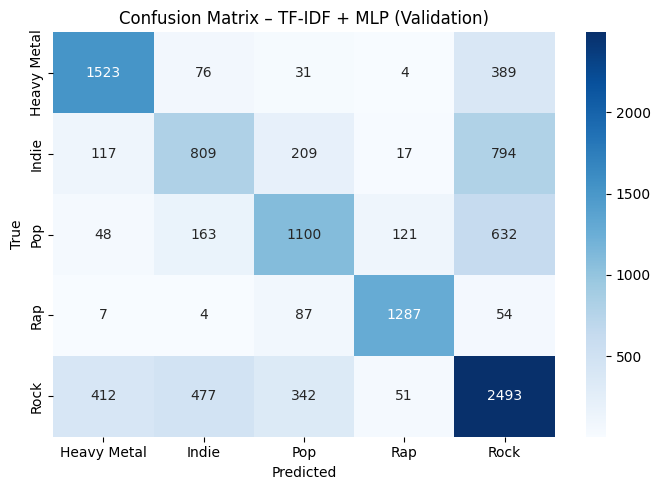

In [13]:
y_val_pred_mlp  = mlp.predict(X_val_tfidf)
y_val_proba_mlp = mlp.predict_proba(X_val_tfidf)

print(f"[MLP] Val Accuracy:    {accuracy_score(y_val, y_val_pred_mlp):.4f}")
print(f"[MLP] Val F1 weighted: {f1_score(y_val, y_val_pred_mlp, average='weighted'):.4f}")
print()
print(classification_report(y_val, y_val_pred_mlp, target_names=le.classes_))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred_mlp), annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix – TF-IDF + MLP (Validation)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
!pip install transformers accelerate tqdm

In [25]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from tqdm.auto import tqdm

torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 256
BATCH_SIZE = 16  # riduci a 8 se esaurisci la RAM

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("Tokenizer caricato.")

Device: mps
Tokenizer caricato.


In [15]:
class LyricsDataset(Dataset):
    """
    Dataset PyTorch per lyrics tokenizzati on-the-fly.

    Args:
        texts     : array di stringhe (testi puliti)
        labels    : array di interi (label del genere)
        tokenizer : tokenizer HuggingFace
        max_len   : lunghezza massima in token
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(LyricsDataset(X_train, y_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(LyricsDataset(X_val,   y_val,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(LyricsDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batch — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batch — Train: 3281 | Val: 703 | Test: 703


In [16]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES)
model = model.to(device)
print(f"Parametri trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

NUM_EPOCHS   = 4
LR           = 2e-5
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print(f"Steps totali: {total_steps} | Warmup: {warmup_steps}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parametri trainable: 66,957,317
Steps totali: 13124 | Warmup: 1312


In [23]:
def run_epoch(model, loader, optimizer=None, scheduler=None):
    """Un epoch di train o eval. optimizer=None → modalità eval."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = correct = total = 0
    all_preds, all_probs, all_labels = [], [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, leave=False):
            ids    = batch["input_ids"].to(device)
            mask   = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            out  = model(input_ids=ids, attention_mask=mask, labels=labels)
            loss = out.loss

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            probs = torch.softmax(out.logits, dim=-1)
            preds = probs.argmax(dim=-1)

            total_loss += loss.item() * labels.size(0)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds  .extend(preds.cpu().numpy())
            all_probs  .extend(probs.cpu().detach().numpy())
            all_labels .extend(labels.cpu().numpy())

    return total_loss/total, correct/total, np.array(all_preds), np.array(all_probs), np.array(all_labels)

In [26]:
PATIENCE = 2
best_val_loss  = float("inf")
patience_count = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n{'='*50}  Epoch {epoch}/{NUM_EPOCHS}  {'='*50}")

    tr_loss, tr_acc, *_ = run_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc, *_ = run_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"]  .append(vl_loss)
    history["train_acc"] .append(tr_acc)
    history["val_acc"]   .append(vl_acc)

    print(f"  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}")
    print(f"  Val    loss={vl_loss:.4f}  acc={vl_acc:.4f}")

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        patience_count = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("  → modello salvato")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print("  Early stopping.")
            break

print("\nTraining completato.")


==================================================  Epoch 1/4  ==================================================


  0%|          | 0/3281 [00:00<?, ?it/s]

RuntimeError: Placeholder storage has not been allocated on MPS device!

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
e = range(1, len(history["train_loss"]) + 1)

ax1.plot(e, history["train_loss"], marker="o", label="Train")
ax1.plot(e, history["val_loss"],   marker="o", label="Val")
ax1.set(title="Loss per epoch", xlabel="Epoch", ylabel="Cross-Entropy Loss")
ax1.legend(); ax1.grid(True)

ax2.plot(e, history["train_acc"], marker="o", label="Train")
ax2.plot(e, history["val_acc"],   marker="o", label="Val")
ax2.set(title="Accuracy per epoch", xlabel="Epoch", ylabel="Accuracy")
ax2.legend(); ax2.grid(True)

plt.suptitle("DistilBERT – Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Carica miglior checkpoint
model.load_state_dict(torch.load("best_model.pt", map_location=device))

# Predizioni su test
_, _, bert_pred, bert_proba, bert_true = run_epoch(model, test_loader)
mlp_pred  = mlp.predict(X_test_tfidf)
mlp_proba = mlp.predict_proba(X_test_tfidf)

def stampa_metriche(y_true, y_pred, y_proba, nome):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average="macro")
    f1_wt  = f1_score(y_true, y_pred, average="weighted")
    yb     = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc    = roc_auc_score(yb, y_proba, multi_class="ovr", average="macro")
    print(f"\n{'─'*45}")
    print(f"  {nome}")
    print(f"{'─'*45}")
    print(f"  Accuracy:      {acc:.4f}")
    print(f"  F1 macro:      {f1_mac:.4f}")
    print(f"  F1 weighted:   {f1_wt:.4f}")
    print(f"  ROC-AUC OvR:   {roc:.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return {"model": nome, "accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_wt, "roc_auc": roc}

res_mlp  = stampa_metriche(y_test,    mlp_pred,  mlp_proba,  "TF-IDF + MLP")
res_bert = stampa_metriche(bert_true, bert_pred, bert_proba, "DistilBERT")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, pred, true, title in [
    (axes[0], mlp_pred,  y_test,    "TF-IDF + MLP"),
    (axes[1], bert_pred, bert_true, "DistilBERT")
]:
    sns.heatmap(confusion_matrix(true, pred), annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set(title=f"Confusion Matrix – {title} (Test)", ylabel="True", xlabel="Predicted")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame([res_mlp, res_bert]).set_index("model")
metrics_df[["accuracy", "f1_macro", "f1_weighted", "roc_auc"]].plot(
    kind="bar", figsize=(9, 4), ylim=(0, 1), colormap="Set2", edgecolor="black")
plt.title("Confronto modelli – Test Set")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
yb = label_binarize(bert_true, classes=list(range(NUM_CLASSES)))
plt.figure(figsize=(9, 6))
for i, (genre, color) in enumerate(zip(le.classes_, plt.cm.tab10.colors)):
    fpr, tpr, _ = roc_curve(yb[:, i], bert_proba[:, i])
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{genre} (AUC={auc(fpr, tpr):.2f})")
plt.plot([0,1],[0,1],"k--",lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves – DistilBERT (one-vs-rest, test set)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

NameError: name 'label_binarize' is not defined

In [ ]:
# Ricostruisci il test DataFrame
_, temp_idx = train_test_split(np.arange(len(df)), test_size=0.30, random_state=SEED, stratify=df["label"])
_, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=df["label"].values[temp_idx])

test_df = df.iloc[test_idx].copy().reset_index(drop=True)
test_df["pred"] = le.inverse_transform(bert_pred)
test_df["true"] = le.inverse_transform(bert_true)
test_df["ok"]   = test_df["pred"] == test_df["true"]
print(f"Corretti: {test_df['ok'].sum()} / {len(test_df)}")

# Coppie più confuse
errors = test_df[~test_df["ok"]]
print("\nCoppie più confuse:")
print(errors.groupby(["true","pred"]).size().reset_index(name="count")
      .sort_values("count", ascending=False).head(8).to_string(index=False))

# Esempi
print("\n" + "="*60)
for _, row in errors.head(3).iterrows():
    print(f"\nVero: {row['true']}  →  Predetto: {row['pred']}")
    print(f"Testo: {row['clean'][:250]}...")
    print("-"*60)

In [ ]:
# Ricostruisci il test DataFrame
_, temp_idx = train_test_split(np.arange(len(df)), test_size=0.30, random_state=SEED, stratify=df["label"])
_, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=df["label"].values[temp_idx])

test_df = df.iloc[test_idx].copy().reset_index(drop=True)
test_df["pred"] = le.inverse_transform(bert_pred)
test_df["true"] = le.inverse_transform(bert_true)
test_df["ok"]   = test_df["pred"] == test_df["true"]
print(f"Corretti: {test_df['ok'].sum()} / {len(test_df)}")

# Coppie più confuse
errors = test_df[~test_df["ok"]]
print("\nCoppie più confuse:")
print(errors.groupby(["true","pred"]).size().reset_index(name="count")
      .sort_values("count", ascending=False).head(8).to_string(index=False))

# Esempi
print("\n" + "="*60)
for _, row in errors.head(3).iterrows():
    print(f"\nVero: {row['true']}  →  Predetto: {row['pred']}")
    print(f"Testo: {row['clean'][:250]}...")
    print("-"*60)